In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
import torch
import torch.nn as nn
from torch.nn import functional as F

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# GPT-2's tokenizer
from transformers import GPT2LMHeadModel, GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")

/home/robertcowher/anaconda3/envs/llm_course/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# data hyperparameters
n_vocab = 50257
embed_dim = 768 # 64
seq_len = 256 # context length

# model hyperparameters
n_heads = 12
n_blocks = 12 

# training hyperparameters
batch_size = 16 


In [4]:
# tokenize the text and make it a tensor
# text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
text = requests.get('https://www.gutenberg.org/cache/epub/65473/pg65473.txt').text
all_tokens = torch.tensor( tokenizer.encode(text) )
len(all_tokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (154729 > 1024). Running this sequence through the model will result in indexing errors


154729

In [5]:
train_ratio = 0.9

test_split_point = int(train_ratio*len(all_tokens))

train_data = all_tokens[:test_split_point]
test_data = all_tokens[test_split_point:]

print(len(train_data))
print(len(test_data))

139256
15473


In [6]:
def get_data_batch(training=True):

    if training:
        data = train_data
    else:
        data = test_data

    # This is wrong because it leaves out sequences
    # ix = np.random.randint(0, len(data) - 1, batch_size, dtype=int)

    # X = data[ix] 
    # y = data[ix + 1]

    ix = torch.randint(len(data)-seq_len, size=(batch_size,))

    X = data[ix[:,None] + torch.arange(seq_len)]
    y = data[ix[:,None] + torch.arange(1,seq_len+1)]

    return X, y

X, y = get_data_batch()

print(X.shape)

torch.Size([16, 256])


In [7]:
class MultiHeadAttention(nn.Module):
  def __init__(self):
    super().__init__()

    # number of attention heads
    self.num_heads = n_heads
    self.head_dim  = embed_dim // n_heads

    # the three Q,K,V weights matrices are initialized as one, and are split inside forward()
    self.QKV = nn.Linear(embed_dim, 3*embed_dim, bias=True)

    # linear mixing after attention
    self.W0 = nn.Linear(embed_dim, embed_dim, bias=True)


  def forward(self,x):

    # sizes for later use
    B, T, E = x.shape # [batch, seq_len, embed_dim]

    # push data through Q, K, and V in one concatenated matrix
    qkv = self.QKV(x) # [batch, sequence, 3*embed]
    q,k,v = torch.split(qkv,E,dim=2) # each matrix is [B, T, E]

    # reshape to [B, T, nHeads, head_dim]
    #  and then transpose to [B, nHeads, T, head_dim]
    q = q.view(B, T, self.num_heads, self.head_dim).transpose(1,2) # [B, nHeads, T, head_dim]
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1,2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1,2)

    # Pytorch's dot-product attention function handles multi-head shapes
    out = F.scaled_dot_product_attention(q, k, v, is_causal=True) # [B, nHeads, T, head_dim]

    # recombine heads: (B, nHeads, T, head_dim) -> [B, T, E]
    out = out.transpose(1,2).view(B, T, E)

    # finally, linearly mix the attention heads
    out = self.W0(out)

    return out

class TransformerBlock(nn.Module):
  def __init__(self):
    super().__init__()

    ### attention subblock
    self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)
    self.attn = MultiHeadAttention()


    ### linear feedforward (MLP) subblock
    self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
    # 4x expansion, then back to embedding size
    self.mlp_1 = nn.Linear(embed_dim, 4*embed_dim, bias=True)
    self.gelu  = nn.GELU()
    self.mlp_2 = nn.Linear(4*embed_dim, embed_dim, bias=True)

  def forward(self, x):

    # attention
    x_att = self.layernorm_1(x) # pre-attention normalization
    x_att = x + self.attn(x_att) # run through attention, then add pre-attention activation ("residual")


    # MLP
    x_ff = self.layernorm_2(x_att) # pre-MLP normalization
    x_ff = x_att + self.mlp_2(self.gelu( self.mlp_1(x_ff) )) # adjustment from expansion-contraction

    return x_ff


class LanguageModel(nn.Module):
  def __init__(self):
    super().__init__()

    # token + position embeddings
    self.wte = nn.Embedding(n_vocab, embed_dim) # token embedding
    self.wpe = nn.Embedding(seq_len, embed_dim) # position embedding

    # transformer blocks
    self.transformerBlocks = nn.Sequential(*[TransformerBlock() for _ in range(n_blocks)])

    # final layernorm
    self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)

    # lm head, with weights tied to token embedding
    self.final_head = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_head.weight = nn.Parameter(self.wte.weight)


  def forward(self, idx):

    # token + position embeddings (note the device!)
    token_emb = self.wte(idx) # [B, T, E]
    posit_emb = self.wpe(torch.arange(idx.shape[-1],device=device)) # [T, E]
    x = token_emb + posit_emb # [B, T, E]

    # pass through each transformer block
    x = self.transformerBlocks(x)

    # final layernorm and unembeddings
    x = self.layernorm_final(x)
    logits = self.final_head(x)  # [B, T, n_vocab]

    return logits


  def generate(self, idx, temperature=1., max_new_tokens=50):

    for _ in range(max_new_tokens):

      # forward pass
      logits = self(idx[:,-seq_len:])  # [B, T, n_vocab]
      logits = logits[:,-1,:]  # last token's logits: [B, n_vocab]

      # apply temperature + softmax
      probs = F.softmax(logits/temperature, dim=-1) # [B, n_vocab]

      # sample next token
      idx_next = torch.multinomial(probs, num_samples=1) # [B, 1]

      # append
      idx = torch.cat((idx, idx_next), dim=1) # [B, T+1]
    return idx


In [8]:
model = LanguageModel().to(device)

In [ ]:
# Test the model before training
def live_test():
    with torch.no_grad():
        X, y = get_data_batch()

        startToks = torch.tensor(tokenizer.encode('The man-mountain shall not depart from our'))

        startToks = startToks.unsqueeze(0).to(device)

        generated_tokens = model.generate(startToks)

        generated_text = tokenizer.decode(generated_tokens[0])

        return generated_text

live_test()

'The man-mountain shall not depart from our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our our'

In [10]:
epochs = 501 
learning_rate = 0.001

loss_function = nn.NLLLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

all_losses = torch.zeros(epochs)
all_test_losses = torch.zeros(epochs)

for i in range(epochs):
    X, y = get_data_batch()

    log_probs = model(X.to(device))

    # calculate the losses on the (reshaped) final target word
    log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1]) # tokens 0:N-1
    y_flat = y[:,1:].reshape(-1) # tokens 1:N

    loss = loss_function(F.log_softmax(log_probs_flat/np.sqrt(embed_dim), dim=-1).cpu(), y_flat)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    all_losses[i] = loss.item()

    if(i % 100 == 0):
        with torch.no_grad():
            X_test, y_test = get_data_batch(training=False)
            test_log_probs = model(X_test.to(device))
            test_log_probs_flat = test_log_probs[:,:-1,:].reshape(-1,test_log_probs.shape[-1]) # tokens 0:N-1
            y_test_flat = y_test[:,1:].reshape(-1) # tokens 1:N
            test_loss = loss_function(F.log_softmax(test_log_probs_flat/np.sqrt(embed_dim), dim=-1).cpu(), y_test_flat)

            all_test_losses[i] = test_loss.item()

            print(f"Completed epoch {i} with training loss {loss.item()} and test loss {test_loss.item()}")


     

Completed epoch 0 with training loss 17.061992645263672 and test loss 10.356541633605957
Completed epoch 100 with training loss 6.346556663513184 and test loss 6.879133224487305
Completed epoch 200 with training loss 6.014427185058594 and test loss 6.5872321128845215
Completed epoch 300 with training loss 5.602707386016846 and test loss 6.254913806915283
Completed epoch 400 with training loss 5.43747091293335 and test loss 6.75755500793457
Completed epoch 500 with training loss 5.282982349395752 and test loss 6.625413417816162


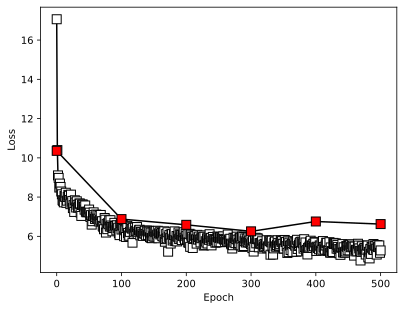

In [11]:
plt.plot(all_losses,'ks-',markerfacecolor='w',markersize=9)
plt.plot(range(0, epochs, 100), all_test_losses[::100],'ks-',markerfacecolor='r',markersize=9)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()

In [12]:
live_test()

'The man-mountain shall not depart from our and,\r\rthe of,\r\rthe of, the of, the of, the of, the of\rthe of, the of, the of, the of,\rthe of,\rthe of,\rthe of, the of'